In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as pkl

In [14]:
# import CellTable_CleanCohort/neighbours_matrix_pretreatment.pkl
# using pkl 
pkl_file = 'CellTable_CleanCohort/neighbours_matrix_pretreatment.pkl'
with open(pkl_file, 'rb') as f:
    neighbors_pretreatment = pkl.load(f)

pkl_file = 'CellTable_CleanCohort/neighbours_matrix_nonresponders.pkl'
with open(pkl_file, 'rb') as f:
    neighbors_nonresponders = pkl.load(f)

In [15]:
# load metadata
metadata = pd.read_csv('CellTable_CleanCohort/CleanCohort_Metadata.csv', index_col=0)

In [16]:
# display metadata contents for user overview
metadata

,Biopsy_(Core/Resection),FORCE_cycle,Sample_Type_(pre/post treatment),NACT_Treatment _Group,Response_pCR,RCB_Scores,RCB_Group,Tissue_Format,Extreme_NR,FORCE,Response,Patient_ID,Stain_Batch
LEAP_ID,,,,,,,,,,,,,
LEAP001,Core,FALSE,pre,EC-T-carbo,Non-Responder,3.750,3,FFPE,False,False,Non-Responder,1,1
LEAP002,Resection,FALSE,post,EC-T-carbo,Non-Responder,3.750,3,FFPE,False,False,Non-Responder,1,1
LEAP003,Core,FALSE,pre,EC-T-carbo,Non-Responder,3.834,3,FFPE,False,False,Non-Responder,2,1
LEAP004,Resection,FALSE,post,EC-T-carbo,Non-Responder,3.834,3,FFPE,False,False,Non-Responder,2,1
LEAP005,Core,FALSE,pre,EC-T-carbo,Non-Responder,1.865,2,FFPE,False,False,Non-Responder,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
LEAP146,Core,Cycle2,mid-late,EC-T-carbo,pCR,0.000,0,FROZEN,False,True,Responder,49,7
LEAP147,Core,PreNACT,pre,EC-T-carbo,pCR,0.000,0,FROZEN,False,True,Responder,53,7
LEAP148,Core,Cycle1,mid-early,EC-T-carbo,pCR,0.000,0,FROZEN,False,True,Responder,53,7


In [17]:
# convert from dict to dataframe using keys as index, first column is everything before the first underscore of the key
pretreat_keys = neighbors_pretreatment.keys()
nonresp_keys = neighbors_nonresponders.keys()

pretreat_df = pd.DataFrame(pretreat_keys, columns=['Sample_ID'])
nonresp_df = pd.DataFrame(nonresp_keys, columns = ['Sample_ID'])

In [18]:
# strip the Sample_ID to get the first part before the underscore
pretreat_df['stripped_ID'] = pretreat_df['Sample_ID'].str.split('_').str[0]
nonresp_df['stripped_ID'] = nonresp_df['Sample_ID'].str.split('_').str[0]


In [19]:
# capitalize all letters in stripped_ID
pretreat_df['stripped_ID'].isin(metadata.index)
pretreat_df['stripped_ID'] = pretreat_df['stripped_ID'].str.upper()
nonresp_df['stripped_ID'].isin(metadata.index)
nonresp_df['stripped_ID'] = nonresp_df['stripped_ID'].str.upper()

In [20]:
# some sample_IDs have an letter appended for a different fov, so we need to correct these
pretreat_df['stripped_ID'].isin(metadata.index)
# print the ones that aren't in it - this is a naming issue resolved in the next cells
print(pretreat_df[~pretreat_df['stripped_ID'].isin(metadata.index)])

       Sample_ID stripped_ID
23   Leap084a_10    LEAP084A
28    Leap084a_7    LEAP084A
51    Leap084a_6    LEAP084A
202   Leap084a_1    LEAP084A
283   Leap084a_5    LEAP084A
292   Leap084a_3    LEAP084A
530   Leap084a_8    LEAP084A
533   Leap084a_4    LEAP084A
551  Leap084a_11    LEAP084A
583   Leap084a_9    LEAP084A
590   Leap084a_2    LEAP084A


In [21]:
# none of these in the nonresponders
print(nonresp_df[~nonresp_df['stripped_ID'].isin(metadata.index)])

Empty DataFrame
Columns: [Sample_ID, stripped_ID]
Index: []


In [22]:
# for any entry in stripped_ID that ends in A, remove the A at the end
pretreat_df['stripped_ID'] = pretreat_df['stripped_ID'].str.rstrip('A')

In [23]:
# now all stripped_IDs should be in metadata
print(pretreat_df[~pretreat_df['stripped_ID'].isin(metadata.index)])

Empty DataFrame
Columns: [Sample_ID, stripped_ID]
Index: []


In [28]:
pretreat_df
# check in metadata to confirm that all entries in stripped_ID correspond to pretreatment samples
metadata[metadata.index.isin(pretreat_df['stripped_ID'])]['Sample_Type_(pre/post treatment)'].value_counts()

Sample_Type_(pre/post treatment)
pre    67
Name: count, dtype: int64

In [29]:
# check in metadata to confirm that all entries in stripped_ID correspond to non-responder samples
metadata[metadata.index.isin(nonresp_df['stripped_ID'])]['Sample_Type_(pre/post treatment)'].value_counts()

Sample_Type_(pre/post treatment)
pre     25
post    21
Name: count, dtype: int64

In [30]:
# print an overview of the metadata columns
metadata.columns

Index(['Biopsy_(Core/Resection)', 'FORCE_cycle',
       'Sample_Type_(pre/post treatment)', 'NACT_Treatment _Group',
       'Response_pCR', 'RCB_Scores', 'RCB_Group', 'Tissue_Format',
       'Extreme_NR', 'FORCE', 'Response', 'Patient_ID', 'Stain_Batch'],
      dtype='object')

In [31]:
# define the metadata for pretreatment and non-responders
pretreat_metadata = metadata[metadata.index.isin(pretreat_df['stripped_ID'])]
nonresp_metadata = metadata[metadata.index.isin(nonresp_df['stripped_ID'])]

In [32]:
# create a dictionary with the leapID as key and the corresponding ROIs as value
pretreat_dict = {}
for i in range(len(pretreat_metadata)):
    leapID = pretreat_metadata.index[i]
    rois = pretreat_df[pretreat_df['stripped_ID']==leapID]['Sample_ID'].values
    pretreat_dict[leapID] = rois

In [36]:
nonresp_dict = {}
for i in range(len(nonresp_metadata)):
    leapID = nonresp_metadata.index[i]
    #print(leapID)
    rois = nonresp_df[nonresp_df['stripped_ID']==leapID]['Sample_ID'].values
    nonresp_dict[leapID] = rois

In [37]:
# example of how to access the neighbors matrix for a specific sample
neighbors_pretreatment[pretreat_dict["LEAP011"][0]].loc['Antigen presenting cell','Cancer cell']

np.float64(0.421345927266283)

In [84]:
# function to generate pairwise information for a given celltype1 and celltype2
# this function will return a dataframe with the enrichment of celltype1 and celltype2 for each sample in the sampledict
def gen_pairwise_info(celltype1, celltype2, sampledict, neighbor_matrix_dict):
    pw_info = {}
    for key in sampledict:
        matches = 0
        total = 0
        for i in range(len(sampledict[key])):
            # check if celltype1 and celltype2 are in the columns of neighborhoods[sampledict[key][i]]

            if celltype1 in neighbor_matrix_dict[sampledict[key][i]].columns:
                if celltype2 in neighbor_matrix_dict[sampledict[key][i]].columns:
                    val = neighbor_matrix_dict[sampledict[key][i]].loc[celltype1, celltype2]
                    total += val
                    matches += 1
        if matches == 0:
            print("NULL "+celltype1+"&"+celltype2+" in "+key)
            x = 0 
        else: 
            x = total/matches
        pw_info[key] = x
    # return pw_info
    return pd.DataFrame.from_dict(pw_info, orient="index", columns = ["enrichment"])

In [41]:
# Example usage of the function
y = gen_pairwise_info("Neutrophil","Cancer cell",pretreat_dict, neighbors_pretreatment)
y

,enrichment
LEAP001,-0.603001
LEAP003,0.059745
LEAP005,-0.969392
LEAP008,-1.317487
LEAP009,-0.650432
...,...
LEAP137,-0.818959
LEAP142,-0.132236
LEAP144,-0.207703
LEAP147,-0.636165


In [42]:
# add the enrichment information to the pretreat_metadata dataframe
pretreat_metadata['enrichment_Neutrophil_CancerCell'] = y['enrichment']

/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_4620/3010073927.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pretreat_metadata['enrichment_Neutrophil_CancerCell'] = y['enrichment']


<Axes: xlabel='Response', ylabel='enrichment_Neutrophil_CancerCell'>

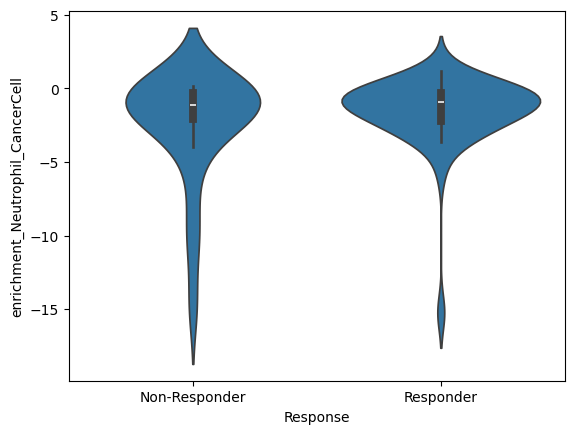

In [43]:
# example violin plot split by "Response"
sns.violinplot(
    x='Response',
    y='enrichment_Neutrophil_CancerCell',
    data=pretreat_metadata,
    inner='box'  # or 'point' or None
)

/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_4620/3167712339.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Response'] = df['Response'].astype('category')
/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_4620/3167712339.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


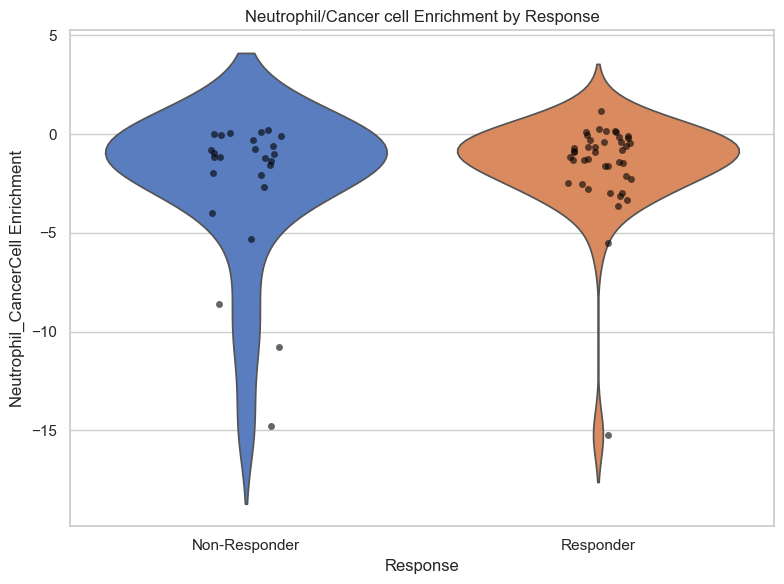

In [44]:
# Example of a violin plot with individual data points overlayed
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: load your DataFrame
# df = pd.read_csv("your_data.csv", index_col=0)
df = pretreat_metadata

# Clean column names if necessary
df.columns = df.columns.str.strip()

# Ensure 'Response' is categorical
df['Response'] = df['Response'].astype('category')

# Set plot style
sns.set(style="whitegrid")

# Create figure
plt.figure(figsize=(8, 6))

# Draw the violin plot
sns.violinplot(
    x='Response',
    y='enrichment_Neutrophil_CancerCell',
    data=df,
    inner=None,           # No inner boxplot for clarity
    palette='muted'
)

# Overlay individual data points
sns.stripplot(
    x='Response',
    y='enrichment_Neutrophil_CancerCell',
    data=df,
    color='black',
    size=5,
    jitter=True,         # Jitter helps avoid overlapping points
    alpha=0.6
)

# Add titles and axis labels
plt.title('Neutrophil/Cancer cell Enrichment by Response')
plt.xlabel('Response')
plt.ylabel('Neutrophil_CancerCell Enrichment')

# Display the plot
plt.tight_layout()
plt.show()


In [45]:
# check if Nans in any of the entries of roi
rois = pretreat_df['Sample_ID'].values
for i in range(len(rois)):
    if np.isnan(neighbors_pretreatment[rois[i]]).any().any():
        print('NAN in mm')
        print(i)
        print(rois[i])
        print('---')

In [46]:
np.isnan(neighbors_pretreatment[rois[0]]).any().any()

np.False_

In [47]:
# CD8 T cells and proliferative cancer cells co-locate more in non-responders
# Memory CD4 T cells and CD8 T cells co-locate more in responders 
# Cancer cells and macrophage+HLA cells co-locate more in non-responders
# B7H4 proliferative cells are closer to non-proliferative cancer cells in responders
nonresp_color = "#70221C"
resp_color = "#306E28"
palette_response = sns.color_palette([nonresp_color, resp_color])

In [48]:
# see that so far the metadata only has the enrichment for Neutrophil and Monocyte
pretreat_metadata

,Biopsy_(Core/Resection),FORCE_cycle,Sample_Type_(pre/post treatment),NACT_Treatment _Group,Response_pCR,RCB_Scores,RCB_Group,Tissue_Format,Extreme_NR,FORCE,Response,Patient_ID,Stain_Batch,enrichment_Neutrophil_CancerCell
LEAP_ID,,,,,,,,,,,,,,
LEAP001,Core,FALSE,pre,EC-T-carbo,Non-Responder,3.750,3,FFPE,False,False,Non-Responder,1,1,-0.603001
LEAP003,Core,FALSE,pre,EC-T-carbo,Non-Responder,3.834,3,FFPE,False,False,Non-Responder,2,1,0.059745
LEAP005,Core,FALSE,pre,EC-T-carbo,Non-Responder,1.865,2,FFPE,False,False,Non-Responder,3,1,-0.969392
LEAP008,Core,FALSE,pre,EC-T-carbo,pCR,0.000,0,FFPE,True,False,Responder,4,1,-1.317487
LEAP009,Core,FALSE,pre,EC-T-carbo,pCR,0.000,0,FFPE,False,False,Responder,5,1,-0.650432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LEAP137,Core,Diagnostic,pre,EC-T-carbo,pCR,0.000,0,FFPE,False,True,Responder,53,6,-0.818959
LEAP142,Core,PreNACT,pre,EC-T-carbo,pCR,0.000,0,FROZEN,False,True,Responder,50,7,-0.132236
LEAP144,Core,PreNACT,pre,EC-T-carbo,pCR,0.000,0,FROZEN,False,True,Responder,49,7,-0.207703


In [49]:
# example of how to access the neighbors matrix for a specific sample
neighbors_pretreatment['Leap084a_11']

,Antigen presenting cell,B7H4 Cancer cell,B7H4 Cancer cell Prol,CD8 T cell,Cancer cell,Cancer cell Prol,Cl Monocyte,Endothelial cell,Fibroblast,Int Monocyte,Macrophage M1,Macrophage + HLA,Macrophage M2,Memory CD4 T cell,Memory CD8 T cell,NonCl Monocyte,NK/CD8,Neutrophil,Regulatory T cell
Antigen presenting cell,11.431184,-2.160656,-1.400704,-10.229226,-2.971028,-6.359309,0.067499,6.460621,4.207780,-1.018230,10.270277,5.081353,2.121547,5.843583,-7.402469,0.000000,5.281285,-1.477709,-0.586823
B7H4 Cancer cell,-1.907173,4.409739,2.154348,0.892007,2.790983,2.649705,1.584078,-2.479487,-2.032795,1.054568,0.129548,0.933492,0.097265,-1.540729,-2.550216,-0.614623,-1.330800,1.306469,-0.400364
B7H4 Cancer cell Prol,-1.404973,1.457747,1.290963,1.713892,-1.793550,0.322054,3.912432,-1.079121,-2.294874,-0.331450,0.041246,0.205503,-0.557983,-1.369680,1.182675,-0.314741,-1.715007,-0.518430,-0.234206
CD8 T cell,-10.386196,0.994363,1.197169,30.685680,-5.109698,1.326884,0.830763,-10.168432,-20.201564,-0.895078,-13.472213,-3.934406,-1.937752,-7.812954,-2.969134,2.530936,-9.124156,-2.394883,0.788182
Cancer cell,-2.931023,2.744568,-2.040469,-5.150169,6.796185,10.128780,1.212624,-6.016187,-8.028703,5.166464,-3.859115,-2.354849,-1.442736,-3.724231,7.358327,-0.187593,-4.390520,-0.948081,-1.110642
Cancer cell Prol,-6.700659,2.495599,0.606490,0.848989,10.192277,9.744485,0.208490,-5.691449,-10.503609,-0.146233,-8.131695,-2.500036,-1.213821,-3.907866,5.829132,-0.881970,-4.692063,-1.316593,0.317197
Cl Monocyte,0.094016,1.547494,3.923328,1.030153,1.586882,0.208162,-0.214597,-1.033488,-0.496328,-0.209383,-0.730609,-0.543706,-0.366608,-0.849643,-0.936556,4.405668,-0.064335,-0.269625,-0.142857
Endothelial cell,7.280023,-2.490661,-1.077606,-9.838530,-5.891336,-5.713598,-1.049187,25.023213,9.085529,-0.721388,1.879814,0.846046,3.103433,8.472128,-4.005061,-0.734343,4.260623,-1.120883,-0.433761
Fibroblast,4.271166,-2.779631,-2.288170,-19.993180,-8.215350,-10.718856,-0.076469,9.319820,32.790311,-0.644468,4.995195,-0.447437,-0.378301,1.327658,-6.965992,-1.239881,3.392221,3.271241,-1.075967
Int Monocyte,-1.014924,1.034195,-0.335098,-1.182573,5.096793,-0.148993,-0.206768,-0.718463,-0.044015,-0.125546,0.482543,-0.389249,-0.254878,-0.608763,-0.389186,-0.135388,-0.734632,-0.219786,-0.083960


In [50]:
# generate pairwise information for the other cell selected types and add to the metadata
pretreat_metadata['enrichment_CD8_cancerprolif'] = gen_pairwise_info("CD8 T cell","Cancer cell Prol",pretreat_dict, neighbors_pretreatment)
pretreat_metadata['enrichment_CD4_CD8'] = gen_pairwise_info("CD8 T cell","Memory CD4 T cell",pretreat_dict, neighbors_pretreatment)
pretreat_metadata['enrichment_cancer_macroHLA'] = gen_pairwise_info("Macrophage + HLA","Cancer cell",pretreat_dict, neighbors_pretreatment)
pretreat_metadata['enrichment_b7h4_cancer'] = gen_pairwise_info("B7H4 Cancer cell","Cancer cell",pretreat_dict, neighbors_pretreatment)



/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_4620/2297791384.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pretreat_metadata['enrichment_CD8_cancerprolif'] = gen_pairwise_info("CD8 T cell","Cancer cell Prol",pretreat_dict, neighbors_pretreatment)
/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_4620/2297791384.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pretreat_metadata['enrichment_CD4_CD8'] = gen_pairwise_info("CD8 T cell","Memory CD4 T cell",pretreat_dict, neighbors_

In [51]:
# now the metadata has the enrichment for more cell types we are interested in
pretreat_metadata

,Biopsy_(Core/Resection),FORCE_cycle,Sample_Type_(pre/post treatment),NACT_Treatment _Group,Response_pCR,RCB_Scores,RCB_Group,Tissue_Format,Extreme_NR,FORCE,Response,Patient_ID,Stain_Batch,enrichment_Neutrophil_CancerCell,enrichment_CD8_cancerprolif,enrichment_CD4_CD8,enrichment_cancer_macroHLA,enrichment_b7h4_cancer
LEAP_ID,,,,,,,,,,,,,,,,,,
LEAP001,Core,FALSE,pre,EC-T-carbo,Non-Responder,3.750,3,FFPE,False,False,Non-Responder,1,1,-0.603001,-2.353984,-2.455811,-1.579673,0.572945
LEAP003,Core,FALSE,pre,EC-T-carbo,Non-Responder,3.834,3,FFPE,False,False,Non-Responder,2,1,0.059745,-2.274765,1.829102,0.202240,3.997438
LEAP005,Core,FALSE,pre,EC-T-carbo,Non-Responder,1.865,2,FFPE,False,False,Non-Responder,3,1,-0.969392,0.259908,-2.024902,0.565814,4.749028
LEAP008,Core,FALSE,pre,EC-T-carbo,pCR,0.000,0,FFPE,True,False,Responder,4,1,-1.317487,1.996841,-1.747096,0.203555,7.239825
LEAP009,Core,FALSE,pre,EC-T-carbo,pCR,0.000,0,FFPE,False,False,Responder,5,1,-0.650432,-2.737003,0.185539,-1.284077,7.018835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LEAP137,Core,Diagnostic,pre,EC-T-carbo,pCR,0.000,0,FFPE,False,True,Responder,53,6,-0.818959,-5.040633,4.491899,-0.649243,10.752549
LEAP142,Core,PreNACT,pre,EC-T-carbo,pCR,0.000,0,FROZEN,False,True,Responder,50,7,-0.132236,-3.952504,0.274563,-0.868791,3.761529
LEAP144,Core,PreNACT,pre,EC-T-carbo,pCR,0.000,0,FROZEN,False,True,Responder,49,7,-0.207703,0.799513,2.123881,-1.702593,3.999300


/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_4620/1285519280.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


Text(0, 0.5, 'Enrichment (z-score)')

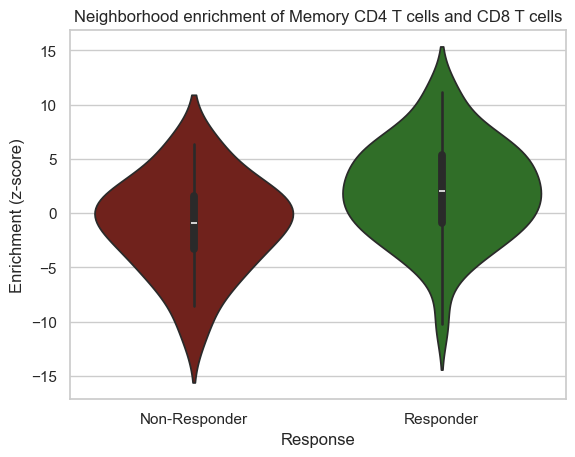

In [52]:
# create violin plots for the enrichment of the different cell types

ax = sns.violinplot(
    x='Response',
    y='enrichment_CD4_CD8',
    data=pretreat_metadata,
    inner='box',  # or 'point' or None
    palette=palette_response,
    saturation = 1
)


ax.set_xlabel("Response")
ax.set_title('Neighborhood enrichment of Memory CD4 T cells and CD8 T cells')
ax.set_ylabel('Enrichment (z-score)')



/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_4620/2900694341.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


Text(0, 0.5, 'Enrichment (z-score)')

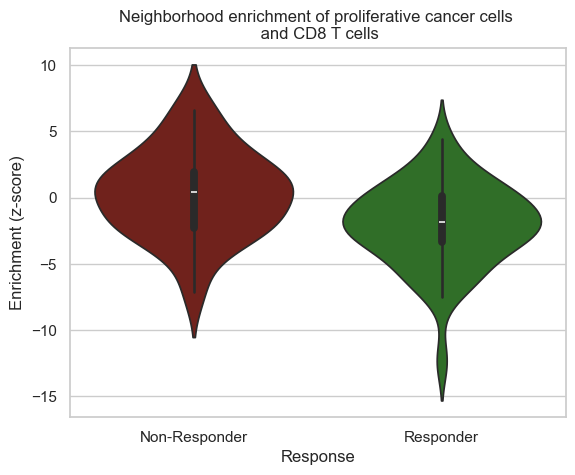

In [53]:



ax = sns.violinplot(
    x='Response',
    y='enrichment_CD8_cancerprolif',
    data=pretreat_metadata,
    inner='box',  # or 'point' or None
    palette=palette_response,
    saturation = 1
)


ax.set_xlabel("Response")
ax.set_title('Neighborhood enrichment of proliferative cancer cells \n and CD8 T cells')
ax.set_ylabel('Enrichment (z-score)')

/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_4620/1470502268.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


Text(0, 0.5, 'Enrichment (z-score)')

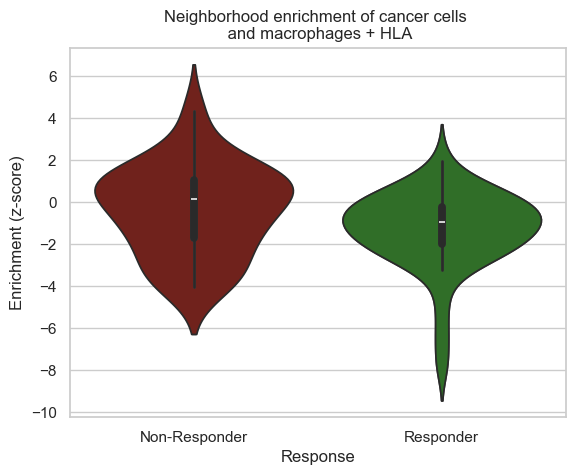

In [54]:
sns.violinplot(
    x='Response',
    y='enrichment_cancer_macroHLA',
    data=pretreat_metadata,
    inner='box'  # or 'point' or None
)



ax = sns.violinplot(
    x='Response',
    y='enrichment_cancer_macroHLA',
    data=pretreat_metadata,
    inner='box',  # or 'point' or None
    palette=palette_response,
    saturation = 1
)


ax.set_xlabel("Response")
ax.set_title('Neighborhood enrichment of cancer cells \n and macrophages + HLA')
ax.set_ylabel('Enrichment (z-score)')


/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_4620/2594614246.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


Text(0, 0.5, 'Enrichment (z-score)')

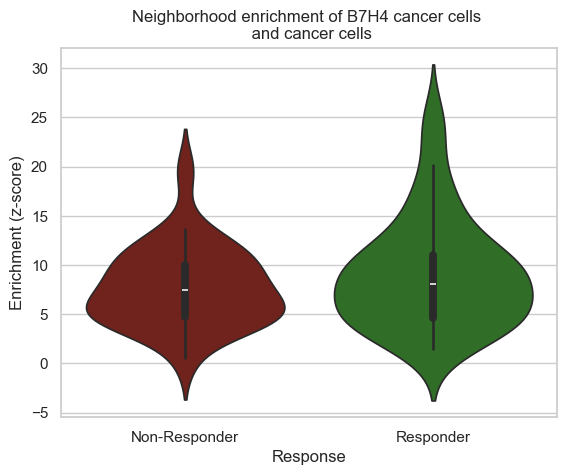

In [55]:




ax = sns.violinplot(
    x='Response',
    y='enrichment_b7h4_cancer',
    data=pretreat_metadata,
    inner='box',  # or 'point' or None
    palette=palette_response,
    saturation = 1
)


ax.set_xlabel("Response")
ax.set_title('Neighborhood enrichment of B7H4 cancer cells \n and cancer cells')
ax.set_ylabel('Enrichment (z-score)')



In [58]:
# now we do the same for the non-responders, generating pairwise information for some pairs of cell types and adding it to the nonresp_metadata dataframe
#“Macrophage”, “Memory CD4 T cell”
#“Antigen presenting cell”, “Regulatory T cell”
#“Monocyte”, “B cell + HLA”
#“Cancer cell Prol”, “CD8 T cell”
#“Fibroblast”, “Macrophage"

nonresp_metadata['enrichment_macroM1_CD4'] = gen_pairwise_info("Macrophage M1", "Memory CD4 T cell",nonresp_dict, neighbors_nonresponders)
nonresp_metadata['enrichment_APC_Treg'] = gen_pairwise_info("Antigen presenting cell", "Regulatory T cell",nonresp_dict, neighbors_nonresponders)
# nonresp_metadata['enrichment_mono_BHLA'] = gen_pairwise_info("Monocyte", "B cell + HLA",nonresp_dict, neighbors_nonresponders)
nonresp_metadata['enrichment_cancerprol_CD8'] = gen_pairwise_info("Cancer cell Prol", "CD8 T cell",nonresp_dict, neighbors_nonresponders)
nonresp_metadata['enrichment_macroM1_fibro'] = gen_pairwise_info("Macrophage M1", "Fibroblast",nonresp_dict, neighbors_nonresponders)



/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_4620/2310330307.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nonresp_metadata['enrichment_macroM1_CD4'] = gen_pairwise_info("Macrophage M1", "Memory CD4 T cell",nonresp_dict, neighbors_nonresponders)
/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_4620/2310330307.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nonresp_metadata['enrichment_APC_Treg'] = gen_pairwise_info("Antigen presenting cell", "Regulatory T cell",nonresp_dict

In [59]:
nonresp_metadata.columns

Index(['Biopsy_(Core/Resection)', 'FORCE_cycle',
       'Sample_Type_(pre/post treatment)', 'NACT_Treatment _Group',
       'Response_pCR', 'RCB_Scores', 'RCB_Group', 'Tissue_Format',
       'Extreme_NR', 'FORCE', 'Response', 'Patient_ID', 'Stain_Batch',
       'enrichment_macro_CD4', 'enrichment_APC_Treg',
       'enrichment_cancerprol_CD8', 'enrichment_macro_fibro',
       'enrichment_macroM1_CD4', 'enrichment_macroM1_fibro'],
      dtype='object')

In [60]:
pre_color = "#D9C454" #np.array([217, 196,84])/255
post_color = "#711F74" # np.array([113, 31,116])/255

In [61]:
# make a seaborn palette with these two colors
palette_prepost = sns.color_palette([pre_color, post_color])

/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_4620/3575776431.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


Text(0, 0.5, 'Enrichment (z-score)')

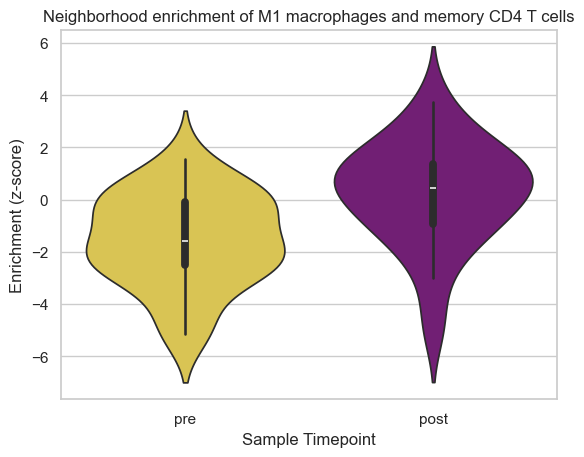

In [63]:
ax = sns.violinplot(
    x='Sample_Type_(pre/post treatment)',
    y='enrichment_macroM1_CD4',
    data=nonresp_metadata,
    inner='box',  # or 'point' or None
    palette=palette_prepost,
    saturation = 1,
)

ax.set_xlabel("Sample Timepoint")
ax.set_title('Neighborhood enrichment of M1 macrophages and memory CD4 T cells')
ax.set_ylabel('Enrichment (z-score)')

/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_4620/1013864631.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


Text(0, 0.5, 'Enrichment (z-score)')

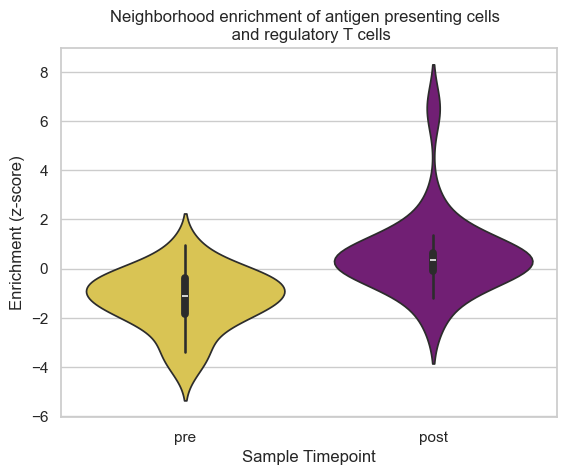

In [64]:
ax = sns.violinplot(
    x='Sample_Type_(pre/post treatment)',
    y='enrichment_APC_Treg',
    data=nonresp_metadata,
    inner='box',  # or 'point' or None
    palette=palette_prepost,
    saturation = 1
)


ax.set_xlabel("Sample Timepoint")
ax.set_title('Neighborhood enrichment of antigen presenting cells  \n and regulatory T cells')
ax.set_ylabel('Enrichment (z-score)')



/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_4620/4016252228.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


Text(0, 0.5, 'Enrichment (z-score)')

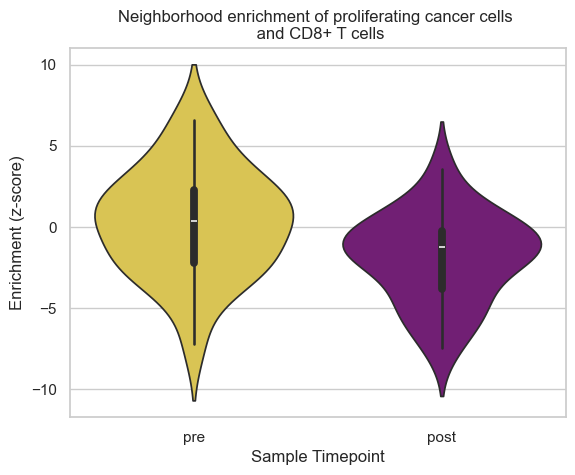

In [65]:

ax = sns.violinplot(
    x='Sample_Type_(pre/post treatment)',
    y='enrichment_cancerprol_CD8',
    data=nonresp_metadata,
    inner='box',  # or 'point' or None
    palette=palette_prepost,
    saturation = 1
)


ax.set_xlabel("Sample Timepoint")
ax.set_title('Neighborhood enrichment of proliferating cancer cells \n and CD8+ T cells')
ax.set_ylabel('Enrichment (z-score)')


/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_4620/1531506093.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


Text(0, 0.5, 'Enrichment (z-score)')

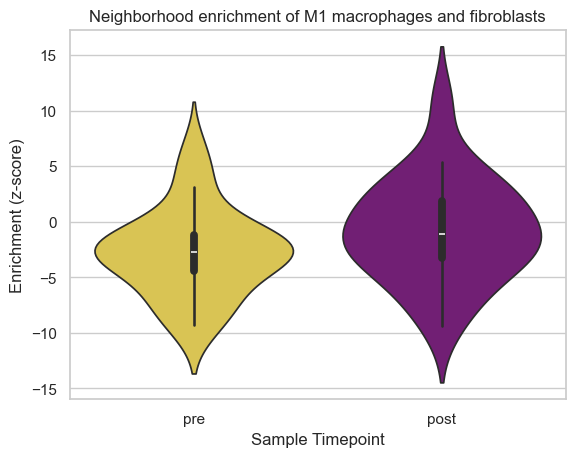

In [66]:

ax = sns.violinplot(
    x='Sample_Type_(pre/post treatment)',
    y='enrichment_macroM1_fibro',
    data=nonresp_metadata,
    inner='box',  # or 'point' or None
    palette=palette_prepost,
    saturation = 1
)


ax.set_xlabel("Sample Timepoint")
ax.set_title('Neighborhood enrichment of M1 macrophages and fibroblasts')
ax.set_ylabel('Enrichment (z-score)')


In [67]:
# save the metadata with the enrichment information to csv files
nonresp_metadata.to_csv("nonresponder_df.csv")

In [68]:
pretreat_metadata.to_csv("pretreat_df.csv")

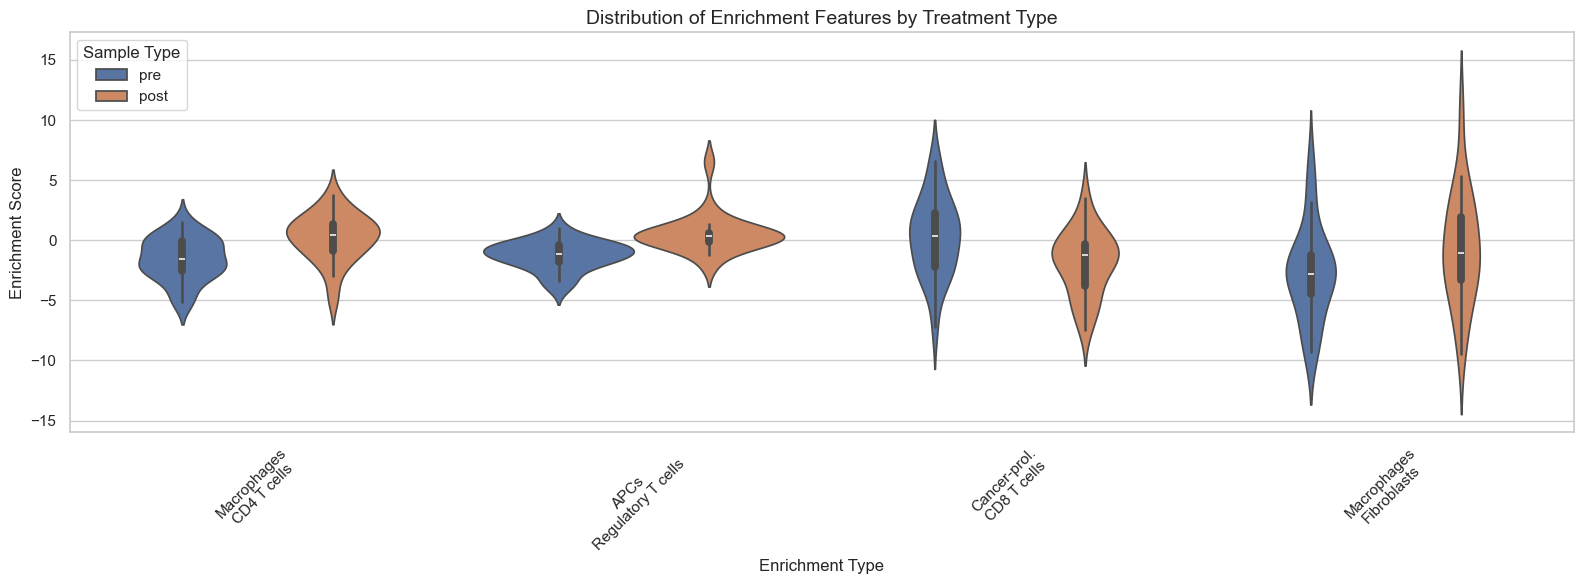

In [70]:
# plot violin plots for multiple pairs of cell types in a single plot
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your CSV file
df = pd.read_csv('nonresponder_df.csv')  # Make sure the file path is correct

# Melt the DataFrame for Seaborn
melted_df = df.melt(
    id_vars='Sample_Type_(pre/post treatment)',
    value_vars=[
        'enrichment_macroM1_CD4',
        'enrichment_APC_Treg',
        'enrichment_cancerprol_CD8',
        'enrichment_macroM1_fibro'
    ],
    var_name='Enrichment_Type',
    value_name='Value'
)

# Optional: Rename enrichment types for better readability
label_map = {
    'enrichment_macroM1_CD4': 'Macrophages\nCD4 T cells',
    'enrichment_APC_Treg': 'APCs\nRegulatory T cells',
    'enrichment_cancerprol_CD8': 'Cancer-prol.\nCD8 T cells',
    'enrichment_macroM1_fibro': 'Macrophages\nFibroblasts'
}

melted_df['Enrichment_Type'] = melted_df['Enrichment_Type'].map(label_map)

# Plot
plt.figure(figsize=(16, 6))
sns.violinplot(
    x='Enrichment_Type',
    y='Value',
    hue='Sample_Type_(pre/post treatment)',
    data=melted_df,
    #split=True
)

# Customize titles and labels
plt.title('Distribution of Enrichment Features by Treatment Type', fontsize=14)
plt.xlabel('Enrichment Type', fontsize=12)
plt.ylabel('Enrichment Score', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend(title='Sample Type')
plt.show()


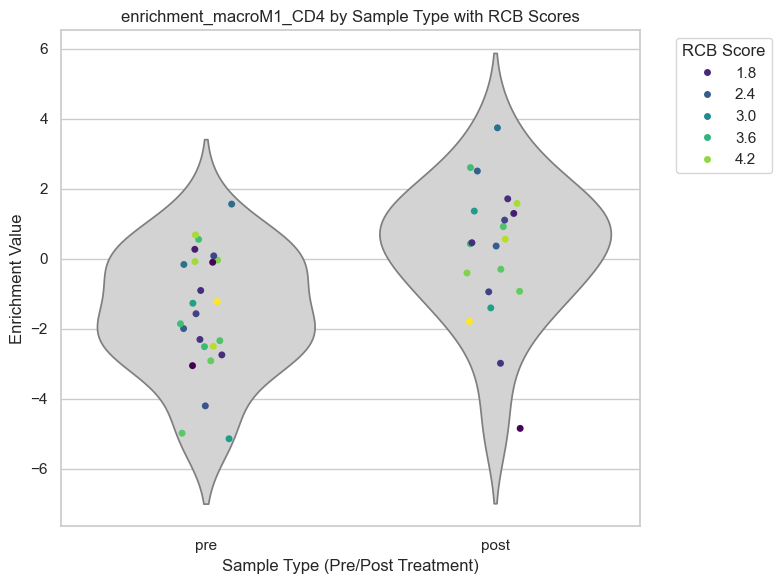

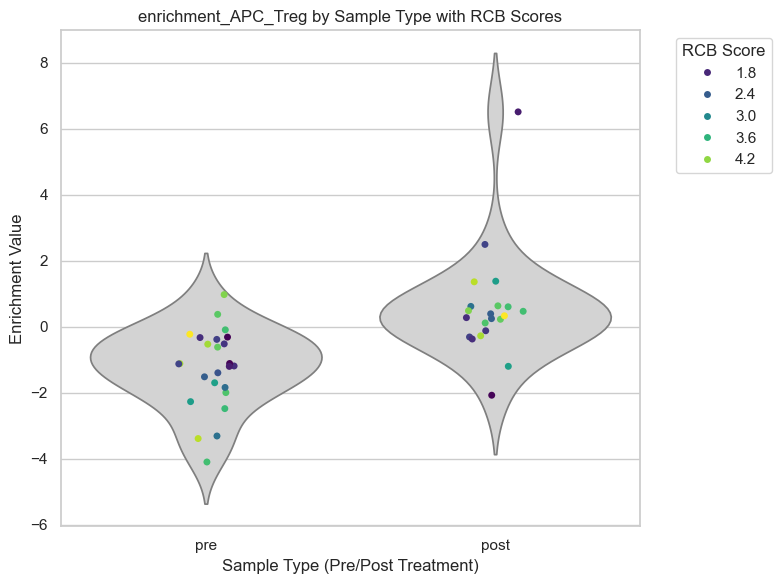

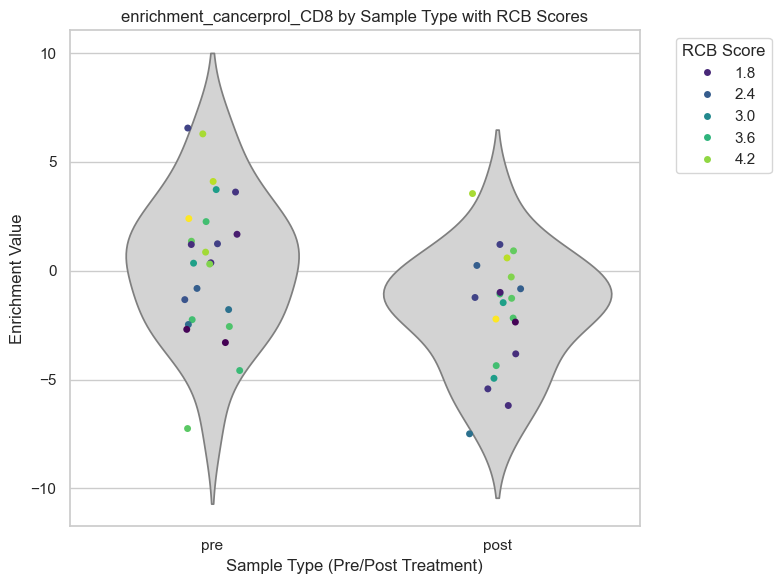

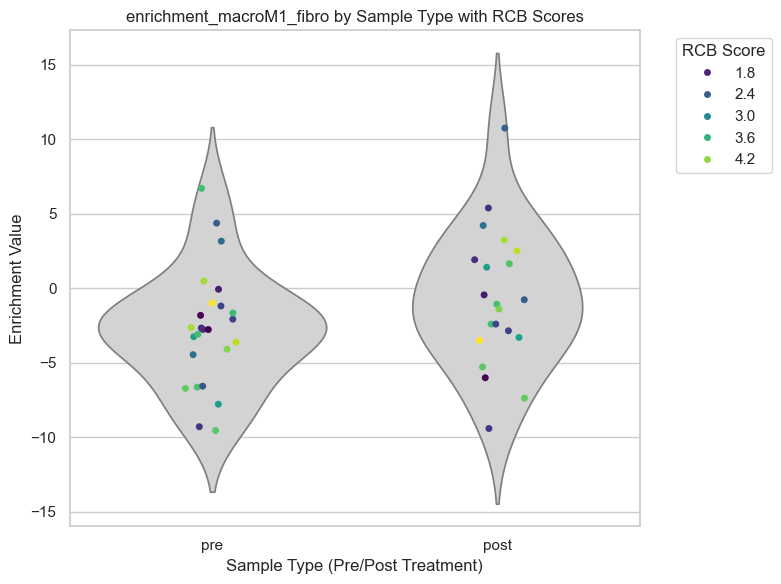

In [71]:
# plot violin plots for each pair of cell types, with individual data points overlayed, colored by RCB_Scores
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("nonresponder_df.csv")

# List of enrichment columns
enrichment_columns = [
    "enrichment_macroM1_CD4",
    "enrichment_APC_Treg",
    "enrichment_cancerprol_CD8",
    "enrichment_macroM1_fibro"
]

# Loop through each enrichment column and plot separately
for column in enrichment_columns:
    plt.figure(figsize=(8, 6))
    
    # Violin plot split by Sample_Type_(pre/post treatment)
    sns.violinplot(
        data=df,
        x="Sample_Type_(pre/post treatment)",
        y=column,
        inner=None,
        color="lightgray"
    )
    
    # Overlay individual data points colored by RCB_Scores
    sns.stripplot(
        data=df,
        x="Sample_Type_(pre/post treatment)",
        y=column,
        hue="RCB_Scores",
        palette="viridis",
        dodge=False,
        jitter=True,
        size=5
    )

    # Customize plot
    plt.title(f"{column} by Sample Type with RCB Scores")
    plt.xlabel("Sample Type (Pre/Post Treatment)")
    plt.ylabel("Enrichment Value")
    plt.legend(title="RCB Score", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


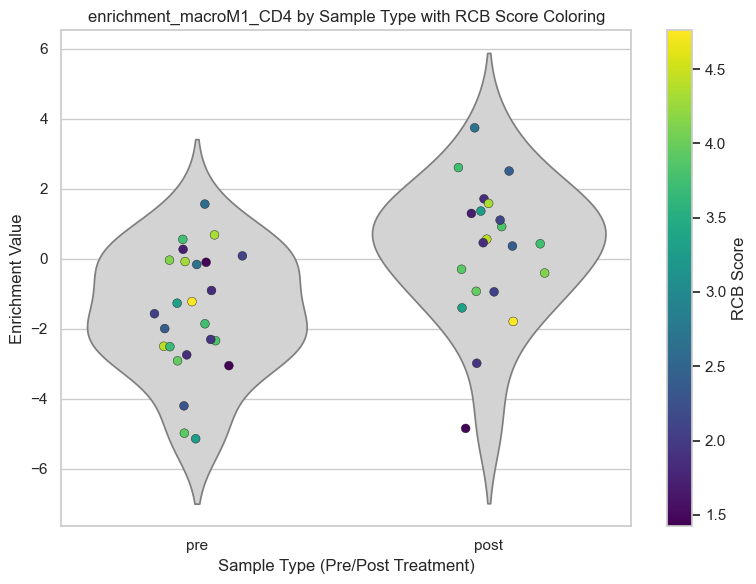

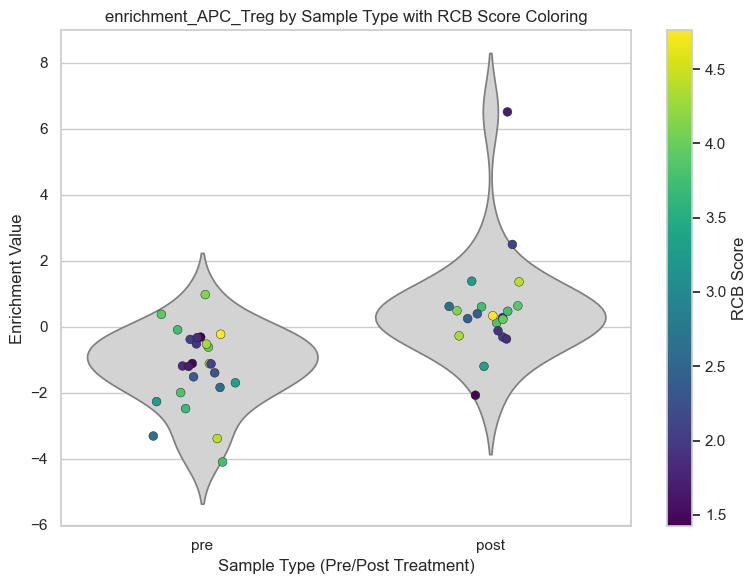

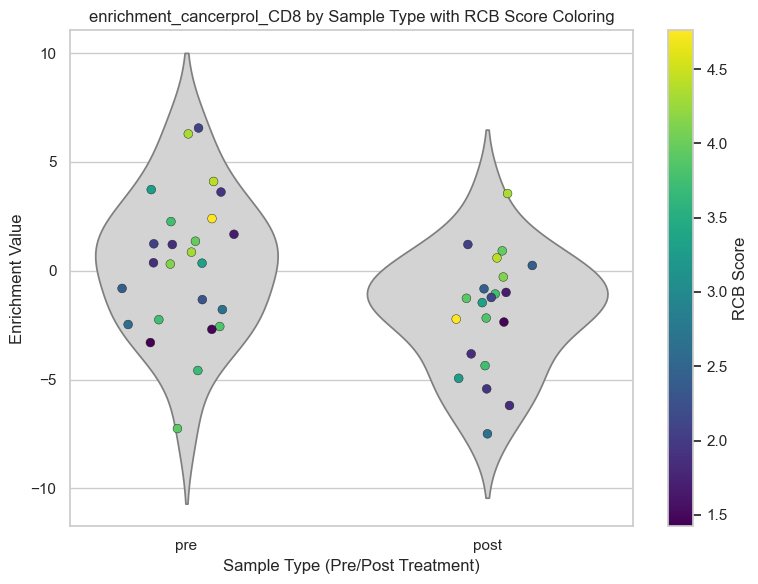

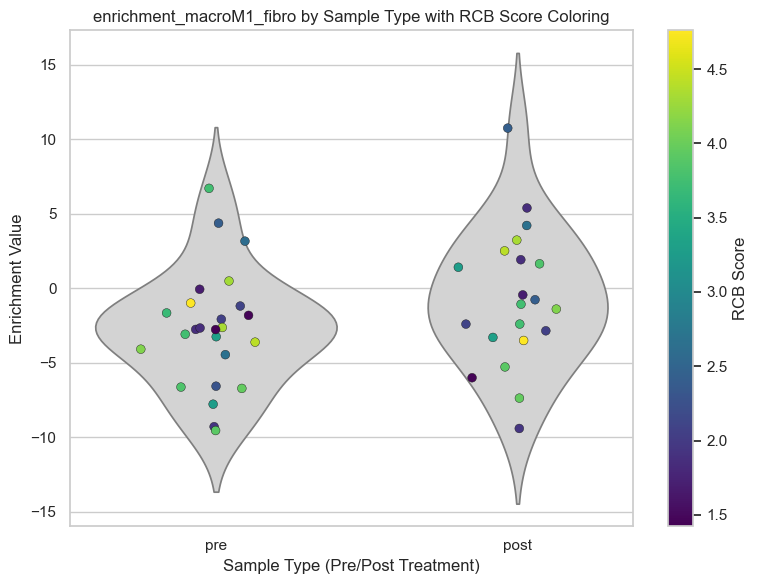

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_csv("nonresponder_df.csv")

# Define enrichment columns
enrichment_columns = [
    "enrichment_macroM1_CD4",
    "enrichment_APC_Treg",
    "enrichment_cancerprol_CD8",
    "enrichment_macroM1_fibro"
]

# Normalize RCB scores for consistent color mapping
rcb_values = df["RCB_Scores"]
vmin, vmax = rcb_values.min(), rcb_values.max()
norm = plt.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.viridis

# Plot loop
for col in enrichment_columns:
    plt.figure(figsize=(8, 6))
    
    # Violin plot
    sns.violinplot(
        data=df,
        x="Sample_Type_(pre/post treatment)",
        y=col,
        inner=None,
        color="lightgray"
    )

    # Overlay colored dots manually
    x_labels = df["Sample_Type_(pre/post treatment)"].unique()
    for i, group in enumerate(x_labels):
        subset = df[df["Sample_Type_(pre/post treatment)"] == group]
        x_coords = np.random.normal(i, 0.08, size=len(subset))  # jitter
        y_coords = subset[col].values
        colors = cmap(norm(subset["RCB_Scores"].values))
        plt.scatter(x_coords, y_coords, c=colors, s=40, edgecolor="k", linewidth=0.3)

    # Colorbar (now explicitly tied to current axes)
    ax = plt.gca()
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("RCB Score")

    # Final plot formatting
    plt.title(f"{col} by Sample Type with RCB Score Coloring")
    plt.xlabel("Sample Type (Pre/Post Treatment)")
    plt.ylabel("Enrichment Value")
    plt.tight_layout()
    plt.show()


In [ ]:
# subset all pairs of cell types to only those where (R - nR) has the same sign and (pre - post), and then rank them by absolute biggest total difference |(R - nR) + (pre - post)|, 
# to give both things that are very different R vs nR and then stay the same post treat-ment, as well as things that consistently get more different post-treatment

,abs_diff
LEAP001,1.809002
LEAP003,0.179235
LEAP005,12.602098
LEAP008,14.492355
LEAP009,3.902594
...,...
LEAP137,18.836060
LEAP142,0.264471
LEAP144,1.869330
LEAP147,8.906305


In [149]:
# make a list of all cell types in any entry of neighbours_pretreatment
all_cell_types = set()
for sample in neighbors_pretreatment.values():
    all_cell_types.update(sample.columns)

# make a list of all cell types in any entry of neighbours_nonresponders
for sample in neighbors_nonresponders.values():
    all_cell_types.update(sample.columns)

# print the cell types
print(all_cell_types)

{'Neutrophil', 'Macrophage + HLA', 'NK/CD8', 'Cancer cell', 'Cancer cell Prol', 'Macrophage M2', 'B7H4 Cancer cell Prol', 'Endothelial cell', 'NonCl Monocyte', 'CD8 T cell', 'Fibroblast', 'Antigen presenting cell', 'Int Monocyte', 'Cl Monocyte', 'Regulatory T cell', 'Memory CD4 T cell', 'B cell + HLA', 'Macrophage M1', 'B7H4 Cancer cell', 'Memory CD8 T cell'}


In [150]:
# loop through all pairs of cell types and calculate the enrichment for each pair in both pretreatment and non-responders
pairwise_enrichment = {}
for cell_type1 in all_cell_types:
    for cell_type2 in all_cell_types:
        if cell_type1 != cell_type2:
            # Calculate enrichment for pretreatment
            pretreat_metadata[cell_type1 + '_' + cell_type2] = gen_pairwise_info(cell_type1, cell_type2, pretreat_dict, neighbors_pretreatment)
            # Calculate enrichment for non-responders
            nonresp_metadata[cell_type1 + "_" + cell_type2] = gen_pairwise_info(cell_type1, cell_type2, nonresp_dict, neighbors_nonresponders)
            
            # separate pretreatment into resonder and non-responder based on metadata
            pretreat_responder_enrichment = pretreat_metadata[pretreat_metadata['Response'] == 'Responder'][cell_type1 + '_' + cell_type2]
            pretreat_nonresp_enrichment = pretreat_metadata[pretreat_metadata['Response'] == 'Non-Responder'][cell_type1 + '_' + cell_type2]

            # seperate nonresp_enrichment into pre and post treatment based on nonresp_metadata
            nonresp_pretreat_enrichment = nonresp_metadata[nonresp_metadata['Sample_Type_(pre/post treatment)'] == 'pre'][cell_type1 + '_' + cell_type2]
            nonresp_posttreat_enrichment = nonresp_metadata[nonresp_metadata['Sample_Type_(pre/post treatment)'] == 'post'][cell_type1 + '_' + cell_type2]

            # Calculate the difference between responder and non-responders in pretreatment
            respnonresp_diff = pretreat_responder_enrichment.mean() - pretreat_nonresp_enrichment.mean()
            # calculate the difference between pre and post treatment samples in non-responders 'Sample_Type_(pre/post treatment)'
            prepost_diff = nonresp_pretreat_enrichment.mean() - nonresp_posttreat_enrichment.mean()

            # Calculate the absolute difference
            total_diff = respnonresp_diff + prepost_diff # if r-nr and pre-post have the same sign, the absolute difference will be larger, if they have different signs, the absolute difference will be smaller
            
            # Store the results
            pairwise_enrichment[(cell_type1, cell_type2)] = {
                # 'pretreat_responder_enrichment': pretreat_responder_enrichment,
                # 'pretreat_nonresp_enrichment': pretreat_nonresp_enrichment,
                # 'nonresp_pretreat_enrichment': nonresp_pretreat_enrichment,
                # 'nonresp_posttreat_enrichment': nonresp_posttreat_enrichment,
                'respnonresp_diff': respnonresp_diff,
                'prepost_diff': prepost_diff,
                'total_diff': total_diff,
            }

/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_4620/1580153589.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pretreat_metadata[cell_type1 + '_' + cell_type2] = gen_pairwise_info(cell_type1, cell_type2, pretreat_dict, neighbors_pretreatment)
/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_4620/1580153589.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nonresp_metadata[cell_type1 + "_" + cell_type2] = gen_pairwise_info(cell_type1, cell_type2, nonresp_dict, neighbors_nonrespond

NULL Neutrophil&Macrophage M2 in LEAP024
NULL Neutrophil&Macrophage M2 in LEAP024
NULL Neutrophil&NonCl Monocyte in LEAP092
NULL Neutrophil&Int Monocyte in LEAP043
NULL Neutrophil&Int Monocyte in LEAP046
NULL Neutrophil&Int Monocyte in LEAP092
NULL Neutrophil&Int Monocyte in LEAP045
NULL Neutrophil&Int Monocyte in LEAP046
NULL Neutrophil&B cell + HLA in LEAP001
NULL Neutrophil&B cell + HLA in LEAP075
NULL Neutrophil&B cell + HLA in LEAP001
NULL Macrophage + HLA&Macrophage M2 in LEAP024
NULL Macrophage + HLA&Macrophage M2 in LEAP024
NULL Macrophage + HLA&NonCl Monocyte in LEAP092
NULL Macrophage + HLA&Int Monocyte in LEAP043
NULL Macrophage + HLA&Int Monocyte in LEAP046
NULL Macrophage + HLA&Int Monocyte in LEAP075
NULL Macrophage + HLA&Int Monocyte in LEAP092
NULL Macrophage + HLA&Int Monocyte in LEAP045
NULL Macrophage + HLA&Int Monocyte in LEAP046
NULL Macrophage + HLA&B cell + HLA in LEAP001
NULL Macrophage + HLA&B cell + HLA in LEAP075
NULL Macrophage + HLA&B cell + HLA in LEAP001


In [151]:
pairwise_enrichment

{('Neutrophil',
  'Macrophage + HLA'): {'respnonresp_diff': np.float64(-0.06660894746560389), 'prepost_diff': np.float64(-0.17144844331393527), 'total_diff': np.float64(-0.23805739077953916)},
 ('Neutrophil', 'NK/CD8'): {'respnonresp_diff': np.float64(0.3145173378016971),
  'prepost_diff': np.float64(0.5891512817792226),
  'total_diff': np.float64(0.9036686195809197)},
 ('Neutrophil',
  'Cancer cell'): {'respnonresp_diff': np.float64(0.8579302027788607), 'prepost_diff': np.float64(-0.1633928357965484), 'total_diff': np.float64(0.6945373669823123)},
 ('Neutrophil',
  'Cancer cell Prol'): {'respnonresp_diff': np.float64(0.4042784217579676), 'prepost_diff': np.float64(-0.45961863942932113), 'total_diff': np.float64(-0.05534021767135355)},
 ('Neutrophil',
  'Macrophage M2'): {'respnonresp_diff': np.float64(0.07758082762604246), 'prepost_diff': np.float64(-0.11096513737099088), 'total_diff': np.float64(-0.03338430974494842)},
 ('Neutrophil',
  'B7H4 Cancer cell Prol'): {'respnonresp_diff': 